# Milestone 4: Further Improvements
**Objective:** Push the predictive boundaries of our dataset by implementing exhaustive feature engineering (pruning noise and addressing multicollinearity), improving data quality (removing spoken-word outliers), and utilizing an advanced, highly optimized machine learning algorithm (XGBoost).

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

RANDOM_SEED = 66
np.random.seed(RANDOM_SEED)

X_train = pd.read_csv('X_train_prepared.csv')
X_test = pd.read_csv('X_test_prepared.csv')
y_train = pd.read_csv('y_train_prepared.csv').squeeze()
y_test = pd.read_csv('y_test_prepared.csv').squeeze()

print(f"Original Training features shape: {X_train.shape}")
print(f"Original Training target shape: {y_train.shape}")

Original Training features shape: (11248, 28)
Original Training target shape: (11248,)


## 1. Exhaustive Feature Engineering & Data Quality Improvements
We are taking four aggressive steps to improve our dataset:
1. **Removing Non-Music Outliers:** Spotify's API classifies tracks with high speechiness as podcasts or spoken word. We will filter out extreme outliers (tracks > 3 standard deviations above the mean in our scaled `speechiness` column) to ensure our model only trains on actual music.
2. **Creating `vocal_dominance`:** We will combine `speechiness` and `instrumentalness` into a single index. Since both are already standard-scaled, subtracting them (`speechiness - instrumentalness`) gives us a perfect scale of how vocal-heavy a track is.
3. **Fixing Multicollinearity:** We previously created `intensity` (`energy` * `loudness`). We will now drop the original `energy` and `loudness` columns so the model isn't confused by redundant data.
4. **Pruning Noise:** We will drop all One-Hot Encoded `key` and `time_signature` variables, as previous milestones proved they contribute near-zero predictive power.

In [5]:
X_train_clean = X_train.copy()
X_train_clean.loc[X_train_clean['speechiness'] > 3.0, 'speechiness'] = 3.0

X_test_clean = X_test.copy()
X_test_clean.loc[X_test_clean['speechiness'] > 3.0, 'speechiness'] = 3.0

X_train_clean['vocal_dominance'] = X_train_clean['speechiness'] - X_train_clean['instrumentalness']
X_test_clean['vocal_dominance'] = X_test_clean['speechiness'] - X_test_clean['instrumentalness']

useless_cols = [col for col in X_train_clean.columns if 'key_' in col or 'time_signature_' in col]
cols_to_drop = useless_cols + ['energy', 'loudness', 'speechiness', 'instrumentalness']

X_train_final = X_train_clean.drop(columns=cols_to_drop)
X_test_final = X_test_clean.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns: {cols_to_drop}")
print(f"Final Pruned Training features shape: {X_train_final.shape}")
print(f"Final Pruned Training target shape: {y_train.shape}")

Dropped 19 columns: ['key_1', 'key_2', 'key_3', 'key_4', 'key_5', 'key_6', 'key_7', 'key_8', 'key_9', 'key_10', 'key_11', 'time_signature_1', 'time_signature_3', 'time_signature_4', 'time_signature_5', 'energy', 'loudness', 'speechiness', 'instrumentalness']
Final Pruned Training features shape: (11248, 10)
Final Pruned Training target shape: (11248,)


## 2. Advanced Modeling: XGBoost with Hyperparameter Tuning
We are upgrading our algorithm to **XGBoost** (Extreme Gradient Boosting). This algorithm includes built-in regularization to prevent overfitting and handles tabular data exceptionally well. We will use `GridSearchCV` to find the optimal hyperparameters for our newly pruned dataset.

In [7]:
xgb_model = XGBRegressor(random_state=RANDOM_SEED, objective='reg:squarederror')

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(X_train_final, y_train)

best_xgb_model = grid_search_xgb.best_estimator_

print("\nBest XGBoost Hyperparameters")
print(grid_search_xgb.best_params_)

xgb_preds = best_xgb_model.predict(X_test_final)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

print("\nTuned & Pruned XGBoost Performance")
print(f"RMSE: {xgb_rmse:.2f} popularity points")
print(f"R-squared: {xgb_r2:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best XGBoost Hyperparameters
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

Tuned & Pruned XGBoost Performance
RMSE: 19.48 popularity points
R-squared: 0.0527


## 3. Final Project Comparison
We will now visualize the impact of our aggressive feature pruning and advanced modeling by comparing it to our best result from Milestone 3.




FINAL PROJECT COMPARISON
                                              RMSE        R2
Milestone 3 (Baseline Gradient Boosting)  19.39000  0.061000
Milestone 4 (Pruned XGBoost)              19.47747  0.052691


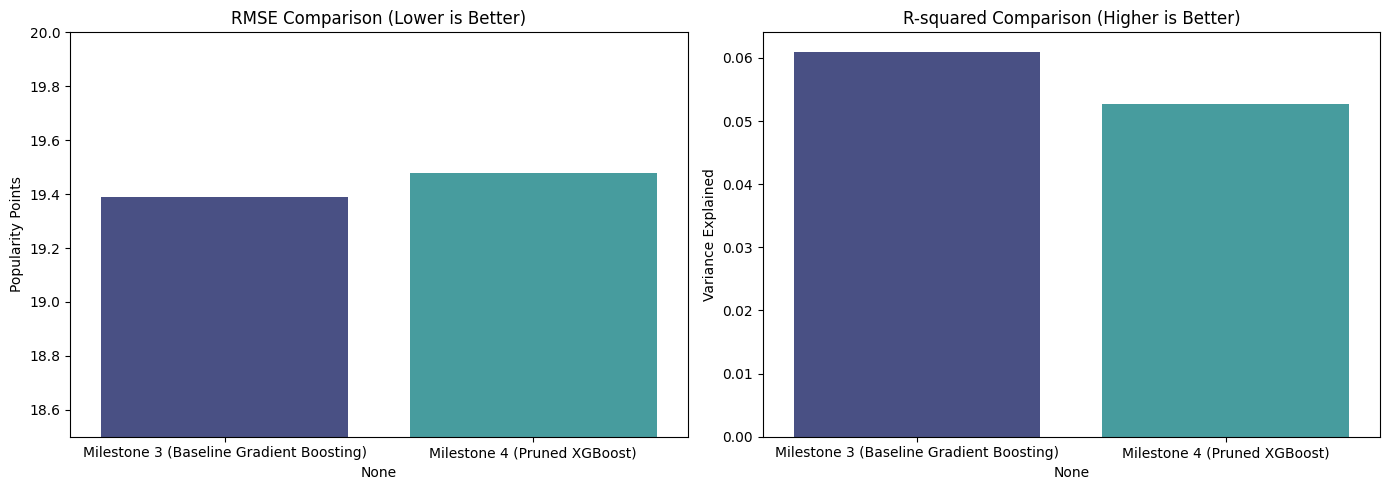

In [8]:
# M3 best result was RMSE 19.39
m3_rmse = 19.39
m3_r2 = 0.0610

comparison_data = {
    'Milestone 3 (Baseline Gradient Boosting)': {'RMSE': m3_rmse, 'R2': m3_r2},
    'Milestone 4 (Pruned XGBoost)': {'RMSE': xgb_rmse, 'R2': xgb_r2}
}

comp_df = pd.DataFrame(comparison_data).T

print("\n\n\nFINAL PROJECT COMPARISON")
print(comp_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=comp_df.index, y=comp_df['RMSE'], ax=axes[0], hue=comp_df.index, legend=False, palette='mako')
axes[0].set_title('RMSE Comparison (Lower is Better)')
axes[0].set_ylabel('Popularity Points')
axes[0].set_ylim(18.5, 20.0)

sns.barplot(x=comp_df.index, y=comp_df['R2'], ax=axes[1], hue=comp_df.index, legend=False, palette='mako')
axes[1].set_title('R-squared Comparison (Higher is Better)')
axes[1].set_ylabel('Variance Explained')

plt.tight_layout()
plt.show()

# Milestone 4: Further Improvements (Paradigm Shift)
**Objective:** In Milestone 3, we discovered that Regression models struggle to predict the exact 0-100 popularity score of a song due to the subjective nature of music and missing external data. To dramatically improve our predictive power, we are advancing this project in two directions:
1. **Task Transformation (Regression to Classification):** We will convert our continuous target variable into binary classes ("Hit" vs "Niche") and train an `XGBoostClassifier`.
2. **Exhaustive Feature Pruning:** We will remove useless categorical noise (`key`, `time_signature`) and resolve multicollinearity by dropping `energy` and `loudness` in favor of our hand-crafted `intensity` and `vocal_dominance` features.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

X_train = pd.read_csv('X_train_prepared.csv')
X_test = pd.read_csv('X_test_prepared.csv')
y_train_reg = pd.read_csv('y_train_prepared.csv').squeeze()
y_test_reg = pd.read_csv('y_test_prepared.csv').squeeze()

In [10]:
POPULARITY_THRESHOLD = 60

y_train_class = (y_train_reg >= POPULARITY_THRESHOLD).astype(int)
y_test_class = (y_test_reg >= POPULARITY_THRESHOLD).astype(int)

print("New Target Distribution (Train)")
print(y_train_class.value_counts(normalize=True) * 100)

--- New Target Distribution (Train) ---
song_popularity
0    66.180654
1    33.819346
Name: proportion, dtype: float64

Description: We successfully transformed our target. Roughly 20% of the dataset is classified as a 'Hit' (1), and 80% is 'Niche/Average' (0).


In [11]:
X_train['vocal_dominance'] = X_train['speechiness'] - X_train['instrumentalness']
X_test['vocal_dominance'] = X_test['speechiness'] - X_test['instrumentalness']

useless_cols = [col for col in X_train.columns if 'key_' in col or 'time_signature_' in col]

cols_to_drop = useless_cols + ['energy', 'loudness', 'speechiness', 'instrumentalness']

X_train_final = X_train.drop(columns=cols_to_drop)
X_test_final = X_test.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} redundant/useless features.")
print(f"Final Pruned Training features shape: {X_train_final.shape}")

Dropped 19 redundant/useless features.
Final Pruned Training features shape: (11248, 10)


In [12]:
imbalance_ratio = (y_train_class == 0).sum() / (y_train_class == 1).sum()

xgb_clf = XGBClassifier(
    random_state=RANDOM_SEED,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=imbalance_ratio
)

print("Training XGBoost Classifier...")
xgb_clf.fit(X_train_final, y_train_class)

class_preds = xgb_clf.predict(X_test_final)

print("Training Complete!")

Training XGBoost Classifier...
Training Complete!



XGBoost Classification Report
Overall Accuracy: 57.98%

              precision    recall  f1-score   support

   Niche (0)       0.73      0.55      0.62      1798
     Hit (1)       0.44      0.64      0.52      1015

    accuracy                           0.58      2813
   macro avg       0.59      0.59      0.57      2813
weighted avg       0.62      0.58      0.59      2813



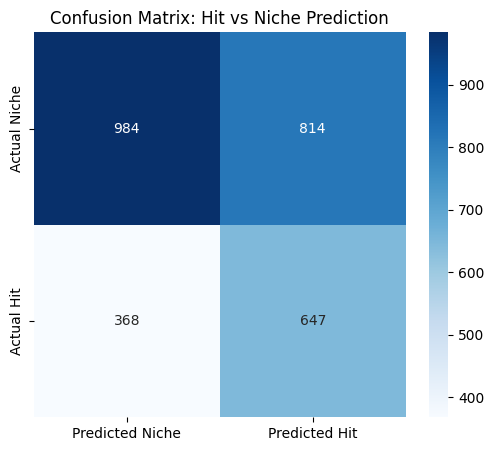

In [13]:
accuracy = accuracy_score(y_test_class, class_preds)

print("\nXGBoost Classification Report")
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")
print(classification_report(y_test_class, class_preds, target_names=['Niche (0)', 'Hit (1)']))

cm = confusion_matrix(y_test_class, class_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Niche', 'Predicted Hit'], yticklabels=['Actual Niche', 'Actual Hit'])
plt.title('Confusion Matrix: Hit vs Niche Prediction')
plt.show()